In [49]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, SparsePauliOp
import numpy as np

In [23]:
theta=np.pi/3

In [43]:
qc = QuantumCircuit(3)
qc.initialize([1, 0], 0)
qc.initialize([1, 0], 1)
qc.initialize([1, 0], 2)
for i in range(3): qc.ry(theta,i)
for i in range(2): qc.cx(i,i+1)
for i in range(3): qc.ry(theta,i)
for i in range(2): qc.cx(i,i+1)
qc.draw()

┌─────────────────┐┌─────────┐     ┌─────────┐                     
q_0: ┤ Initialize(1,0) ├┤ Ry(π/3) ├──■──┤ Ry(π/3) ├─────────────■───────
     ├─────────────────┤├─────────┤┌─┴─┐└─────────┘┌─────────┐┌─┴─┐     
q_1: ┤ Initialize(1,0) ├┤ Ry(π/3) ├┤ X ├─────■─────┤ Ry(π/3) ├┤ X ├──■──
     ├─────────────────┤├─────────┤└───┘   ┌─┴─┐   ├─────────┤└───┘┌─┴─┐
q_2: ┤ Initialize(1,0) ├┤ Ry(π/3) ├────────┤ X ├───┤ Ry(π/3) ├─────┤ X ├
     └─────────────────┘└─────────┘        └───┘   └─────────┘     └───┘

In [56]:
theta_list=np.linspace(0,2*np.pi,20,endpoint=False)
P_OOO=np.empty(20)
ZZZ=np.empty(20)


for j in range(20):
    theta= theta_list[j]

    qc = QuantumCircuit(3)
    qc.initialize([1, 0], 0)
    qc.initialize([1, 0], 1)
    qc.initialize([1, 0], 2)
    for i in range(3): qc.ry(theta,i)
    for i in range(2): qc.cx(i,i+1)
    for i in range(3): qc.ry(theta,i)
    for i in range(2): qc.cx(i,i+1)

    sv = Statevector(qc.reverse_bits())
    P_OOO[j]=abs(sv.data[0])**2
    ZZZ[j]=sv.expectation_value(SparsePauliOp("ZZZ")).real


Matplotlib is building the font cache; this may take a moment.


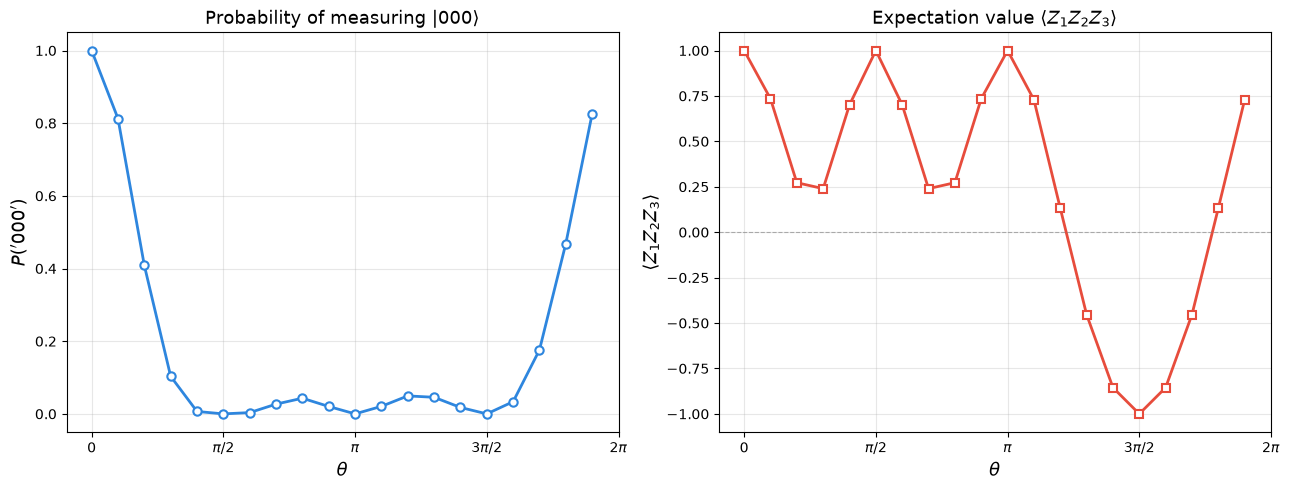

In [57]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 왼쪽: P('000')
axes[0].plot(theta_list, P_OOO, 'o-', color='#2E86DE', lw=2, ms=6,
             mfc='white', mec='#2E86DE', mew=1.5)
axes[0].set_xlabel(r'$\theta$', fontsize=13)
axes[0].set_ylabel(r"$P('000')$", fontsize=13)
axes[0].set_title(r"Probability of measuring $|000\rangle$", fontsize=13)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
axes[0].set_xticklabels(['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])

# 오른쪽: ⟨ZZZ⟩
axes[1].plot(theta_list, ZZZ, 's-', color='#E74C3C', lw=2, ms=6,
             mfc='white', mec='#E74C3C', mew=1.5)
axes[1].axhline(0, color='gray', lw=0.8, ls='--', alpha=0.6)
axes[1].set_xlabel(r'$\theta$', fontsize=13)
axes[1].set_ylabel(r'$\langle Z_1 Z_2 Z_3 \rangle$', fontsize=13)
axes[1].set_title(r'Expectation value $\langle Z_1 Z_2 Z_3 \rangle$', fontsize=13)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(-1.1, 1.1)
axes[1].set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
axes[1].set_xticklabels(['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])

plt.tight_layout()
plt.show()